In [14]:
import seaborn as sns
import scipy.stats as stats
import pandas as pd

In [6]:
data = sns.load_dataset('titanic')
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [12]:
data = data.dropna(subset = ['age'])

In [13]:
alive = data[data['survived'] == 1]['age']
dead = data[data['survived'] == 0]['age']

In [11]:
t_stat, p_value = stats.ttest_ind(alive, dead, equal_var = False)
t_stat, p_value

(-2.0460301043939704, 0.04118965162586639)

In [20]:
contingency = pd.crosstab(data['sex'], data['survived'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print("chi2",chi2)
print("p",p)
print("dof",dof)
print("expected",expected)

chi2 205.02582752855906
p 1.6716678441395297e-46
dof 1
expected [[154.99159664 106.00840336]
 [269.00840336 183.99159664]]


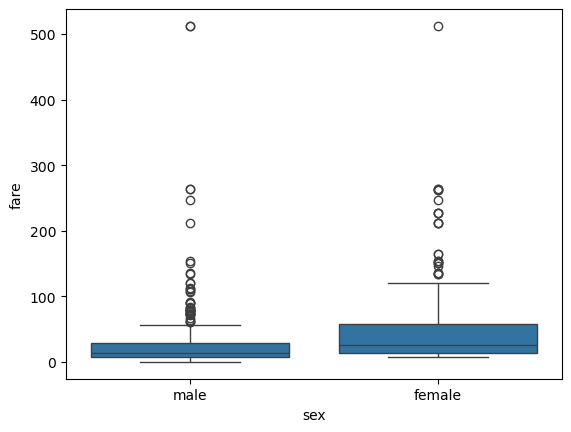

In [24]:
sns.boxplot(x = data['sex'], y = data['fare']);

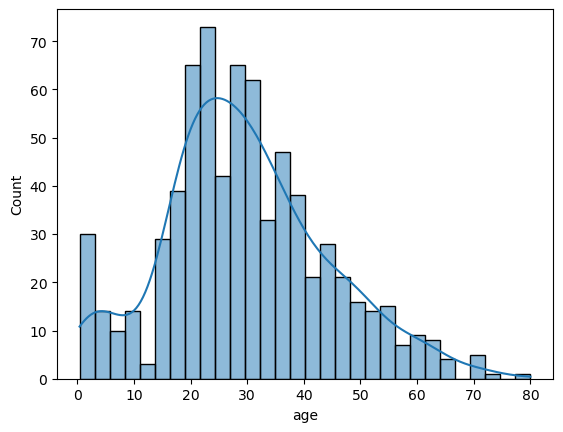

In [37]:
sns.histplot(data['age'], bins = 30, kde = True);

In [36]:
nu_ms = ['age', 'fare']
desc = data[nu_ms].agg(['mean', 'median', 'std'])
sk = data[nu_ms].skew()
k_sis = data[nu_ms].kurt()
print(desc, sk, k_sis)

              age       fare
mean    29.699118  34.694514
median  28.000000  15.741700
std     14.526497  52.918930 age     0.389108
fare    4.653630
dtype: float64 age      0.178274
fare    30.924249
dtype: float64
